In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns
import os
import re

# ==========================================
# PRAWIDŁOWE NOTATKI DLA KLATEK (0 = Dobra, 1 = Zła)
# ==========================================
USER_NOTES_FRAMES = [
    (0, 519, 0),
    (519, 2062, 1),
    (2062, 2068, 0),
    (2068, 2142, 1),
    (2142, 5603, 0),  
    (5603, 6513, 1),
    (6513, 6515, 0),
    (6515, 7654, 1),
    (7654, 7679, 0),
    (7679, 7682, 1),
    (7682, 7909, 0)
]

# Funkcja przypisująca Twoją ocenę do konkretnej klatki
def get_ground_truth_for_frame(frame_num):
    for start, end, label in USER_NOTES_FRAMES:
        if start <= frame_num <= end:
            return label
    return 0  # Domyślnie dobra postawa, jeśli poza zakresem

# 1. Wczytanie danych z modelu (podmień na nazwę swojego pliku CSV z analizy klatek!)
CSV_PATH = "../../data/wyniki_z_klatek.csv"  # Skoków do góry z src/training/ do głównego data/

if not os.path.exists(CSV_PATH):
    print(f"BŁĄD: Nie znaleziono pliku {CSV_PATH}. Upewnij się, że nazwa jest poprawna.")
else:
    df = pd.read_csv(CSV_PATH)



In [4]:
 # 2. Wyciągnięcie numeru klatki z nazwy pliku (np. "frame_000123.jpg" -> 123)
    # Zakładam, że kolumna z nazwą pliku to "frame" (jeśli jest inna, zmień poniżej)
def extract_frame_num(filename):
    numbers = re.findall(r'\d+', str(filename))
    return int(numbers[0]) if numbers else 0

df['frame_num'] = df['frame'].apply(extract_frame_num)
    

In [5]:
 
    # 3. Dodanie Twoich notatek
df['ground_truth'] = df['frame_num'].apply(get_ground_truth_for_frame)

    # Czyszczenie z ewentualnych błędów detekcji (-1 to brak osoby w kadrze)
    # Pamiętaj, żeby upewnić się, że kolumna z oceną algorytmu nazywa się 'prediction' albo 'model_label'
col_name_model = 'prediction' if 'prediction' in df.columns else 'model_label'
df_clean = df[df[col_name_model] != -1].copy()

In [6]:
  

    # 4. Obliczanie metryk
acc = accuracy_score(df_clean['ground_truth'], df_clean[col_name_model])
print(f"\n--- WYNIKI WALIDACJI (NA SUROWYCH KLATKACH) ---")
print(f"Przeanalizowano {len(df_clean)} klatek.")
print(f"Ogólna Dokładność (Accuracy): {acc*100:.2f}%")
print("\nSzczegółowy raport (Precision/Recall):")
print(classification_report(df_clean['ground_truth'], df_clean[col_name_model], target_names=['Dobra (0)', 'Zła (1)']))



--- WYNIKI WALIDACJI (NA SUROWYCH KLATKACH) ---
Przeanalizowano 7910 klatek.
Ogólna Dokładność (Accuracy): 90.81%

Szczegółowy raport (Precision/Recall):
              precision    recall  f1-score   support

   Dobra (0)       0.86      0.99      0.92      4241
     Zła (1)       0.99      0.81      0.89      3669

    accuracy                           0.91      7910
   macro avg       0.92      0.90      0.91      7910
weighted avg       0.92      0.91      0.91      7910



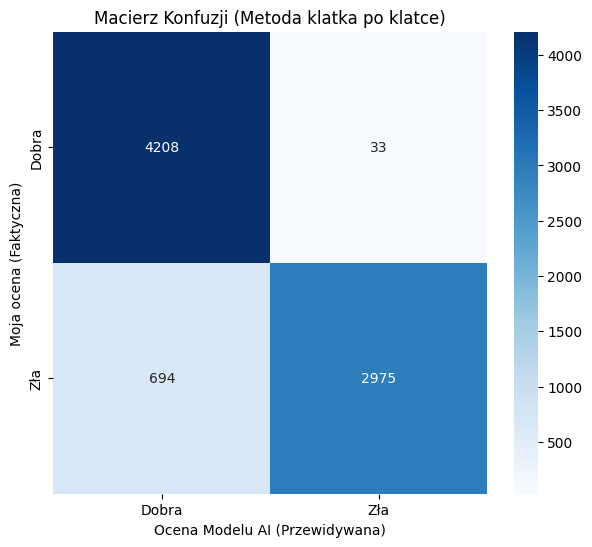

In [9]:

    # 5. Macierz Konfuzji
cm = confusion_matrix(df_clean['ground_truth'], df_clean[col_name_model])
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Dobra', 'Zła'], yticklabels=['Dobra', 'Zła'])
plt.title('Macierz Konfuzji (Metoda klatka po klatce)')
plt.ylabel('Moja ocena (Faktyczna)')
plt.xlabel('Ocena Modelu AI (Przewidywana)')
plt.show()
    

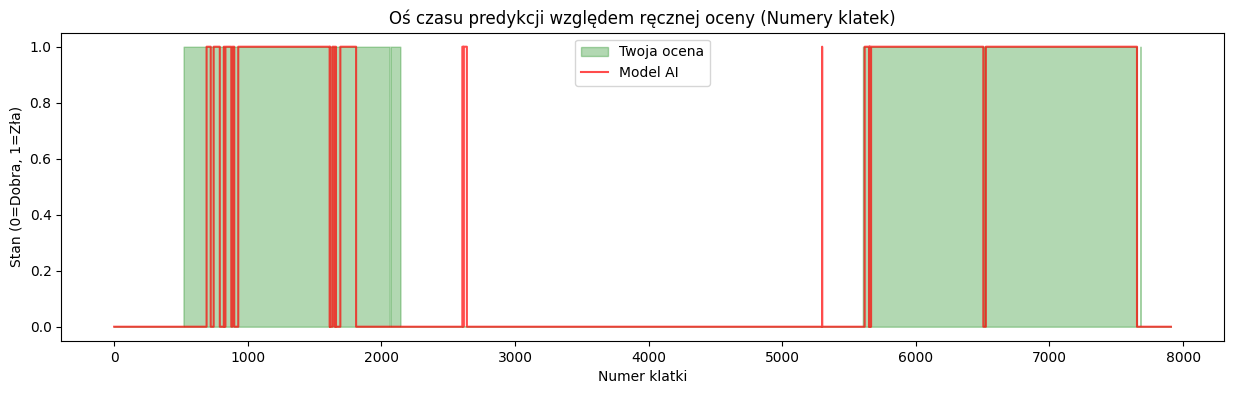

In [8]:

    # 6. Opcjonalnie: Wykres w czasie
plt.figure(figsize=(15, 4))
plt.fill_between(df_clean['frame_num'], df_clean['ground_truth'], color='green', alpha=0.3, label='Twoja ocena')
plt.step(df_clean['frame_num'], df_clean[col_name_model], where='post', color='red', alpha=0.7, label='Model AI')
plt.title('Oś czasu predykcji względem ręcznej oceny (Numery klatek)')
plt.xlabel('Numer klatki')
plt.ylabel('Stan (0=Dobra, 1=Zła)')
plt.legend()
plt.show()

2. Dokładność Pełnego Algorytmu Aplikacji (z buforem): 89.85%

Szczegółowy raport dla Pełnego Algorytmu:
              precision    recall  f1-score   support

   Dobra (0)       0.85      0.99      0.91      4241
     Zła (1)       0.99      0.79      0.88      3669

    accuracy                           0.90      7910
   macro avg       0.92      0.89      0.90      7910
weighted avg       0.91      0.90      0.90      7910



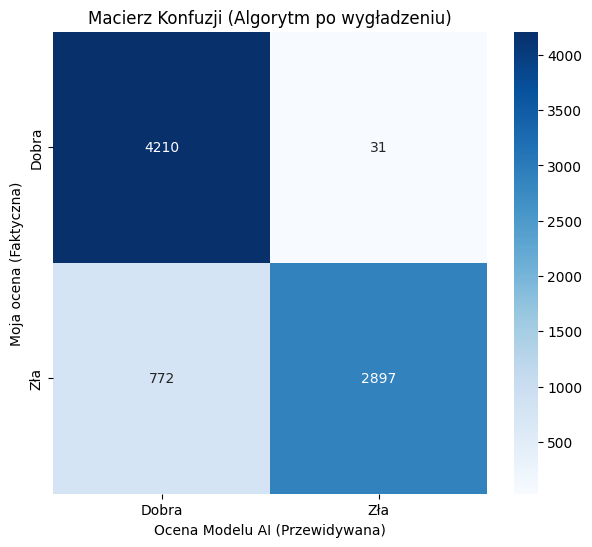

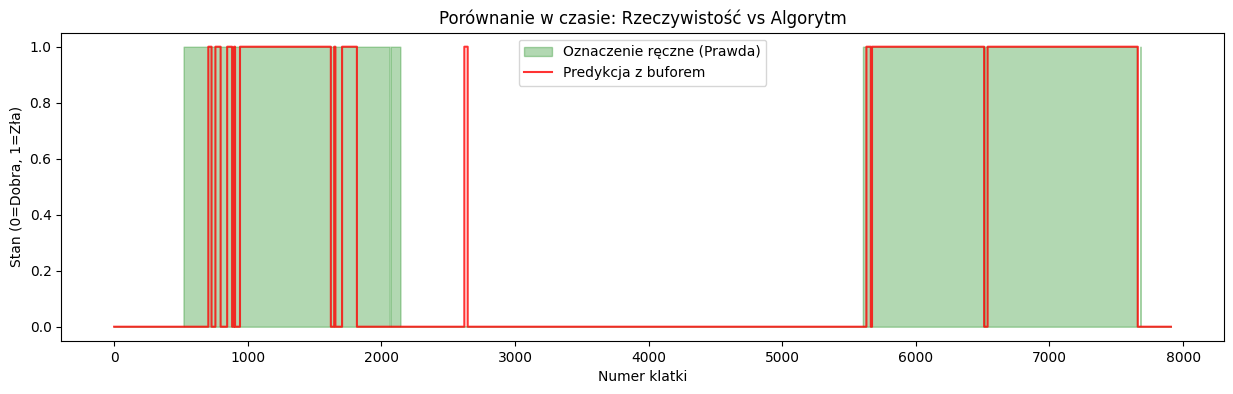

In [11]:

# Odwzorowujemy Twój bufor SMOOTH_N = 20 z pliku server.py
window_size = 20
df_clean['smoothed_prediction'] = df_clean[col_name_model].rolling(window=window_size, min_periods=1).apply(
lambda x: 1 if (x == 1).sum() >= len(x) * 0.7 else 0
)
acc_smooth = accuracy_score(df_clean['ground_truth'], df_clean['smoothed_prediction'])
print(f"2. Dokładność Pełnego Algorytmu Aplikacji (z buforem): {acc_smooth*100:.2f}%")

print("\nSzczegółowy raport dla Pełnego Algorytmu:")
print(classification_report(df_clean['ground_truth'], df_clean['smoothed_prediction'], target_names=['Dobra (0)', 'Zła (1)']))

# Macierz Konfuzji dla Wersji Wygładzonej
cm = confusion_matrix(df_clean['ground_truth'], df_clean['smoothed_prediction'])
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Dobra', 'Zła'], yticklabels=['Dobra', 'Zła'])
plt.title('Macierz Konfuzji (Algorytm po wygładzeniu)')
plt.ylabel('Moja ocena (Faktyczna)')
plt.xlabel('Ocena Modelu AI (Przewidywana)')
plt.show()
    
# Wykres w czasie
plt.figure(figsize=(15, 4))
plt.fill_between(df_clean['frame_num'], df_clean['ground_truth'], color='green', alpha=0.3, label='Oznaczenie ręczne (Prawda)')
plt.step(df_clean['frame_num'], df_clean['smoothed_prediction'], where='post', color='red', alpha=0.8, label='Predykcja z buforem')
plt.title('Porównanie w czasie: Rzeczywistość vs Algorytm')
plt.xlabel('Numer klatki')
plt.ylabel('Stan (0=Dobra, 1=Zła)')
plt.legend()
plt.show()

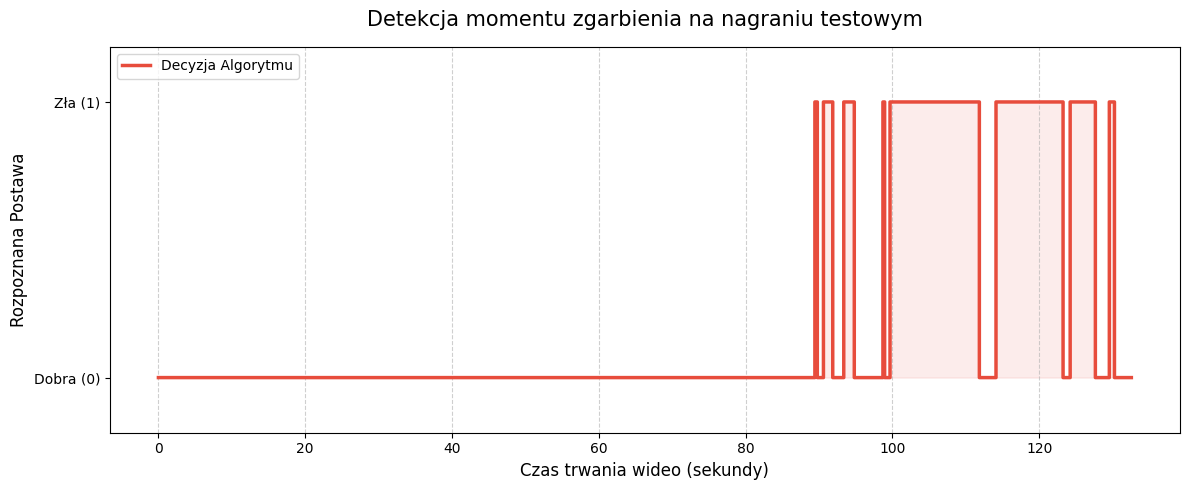


 Algorytm po raz pierwszy wykrył  złą postawę w 89.4 sekundzie nagrania.


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# ==========================================
# Wczytanie wyników z pliku CSV
# ==========================================
# Zwróć uwagę na ścieżkę - dostosuj ją, jeśli plik zapisał się w innym miejscu
CSV_PATH = "../../data/wyniki_profesor.csv" 

if not os.path.exists(CSV_PATH):
    # Awaryjne sprawdzenie w obecnym folderze
    CSV_PATH = "wyniki_profesor.csv"

if not os.path.exists(CSV_PATH):
    print(f"❌ BŁĄD: Nie znaleziono pliku wyników. Upewnij się, że skrypt ewaluacyjny zakończył pracę.")
else:
    df = pd.read_csv(CSV_PATH)
    
    # Przeliczamy klatki na przybliżony czas w sekundach (przy założeniu 30 FPS)
    # Dzięki temu wykres będzie czytelniejszy
    FPS = 30.0
    df['czas_sekundy'] = df['frame'] / FPS

    # ==========================================
    # Generowanie Wykresu
    # ==========================================
    plt.figure(figsize=(12, 5))
    
    # Używamy wykresu schodkowego (step), który najlepiej oddaje stany 0/1
    plt.step(df['czas_sekundy'], df['model_label'], where='post', color='#e74c3c', linewidth=2.5, label='Decyzja Algorytmu')
    
    # Dodajemy estetyczne tło
    plt.fill_between(df['czas_sekundy'], df['model_label'], color='#e74c3c', alpha=0.1)

    # Upiększanie wykresu dla Profesora
    plt.title('Detekcja momentu zgarbienia na nagraniu testowym', fontsize=15, pad=15)
    plt.xlabel('Czas trwania wideo (sekundy)', fontsize=12)
    plt.ylabel('Rozpoznana Postawa', fontsize=12)
    
    # Zmieniamy podpisy osi Y na czytelny tekst
    plt.yticks([0, 1], ['Dobra (0)', 'Zła (1)'])
    
    # Ustawiamy limity osi Y, żeby wykres był wyśrodkowany
    plt.ylim(-0.2, 1.2)
    
    plt.grid(True, linestyle='--', alpha=0.6, axis='x')
    plt.legend(loc='upper left')
    plt.tight_layout()
    
    # Wyświetlamy
    plt.show()
    
    # Opcjonalnie: Znajdujemy dokładną sekundę, w której Profesor się zgarbił
    zla_postawa = df[df['model_label'] == 1]
    if not zla_postawa.empty:
        moment_zgarbienia = zla_postawa['czas_sekundy'].iloc[0]
        print(f"\n Algorytm po raz pierwszy wykrył  złą postawę w {moment_zgarbienia:.1f} sekundzie nagrania.")
    else:
        print("\nℹ️ Algorytm nie wykrył złej postawy na całym nagraniu.")

--- WYNIKI DLA VIDEO PROF ---
Dokładność Modelu AI: 79.73%

Szczegółowy raport (Precision/Recall):
              precision    recall  f1-score   support

   Dobra (0)       0.74      1.00      0.85      2309
     Zła (1)       1.00      0.52      0.68      1667

    accuracy                           0.80      3976
   macro avg       0.87      0.76      0.77      3976
weighted avg       0.85      0.80      0.78      3976



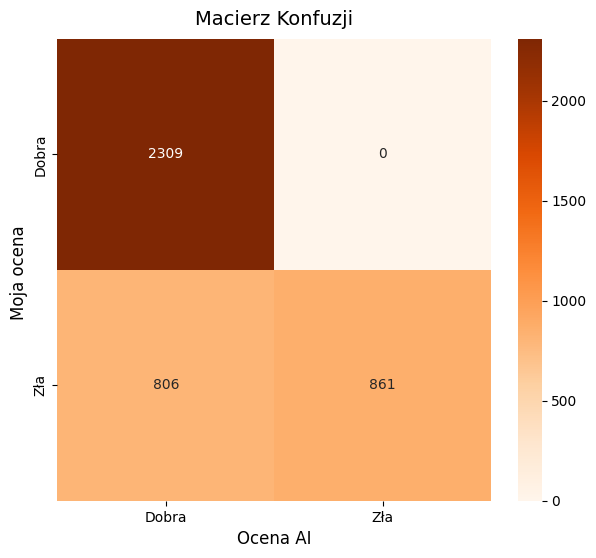

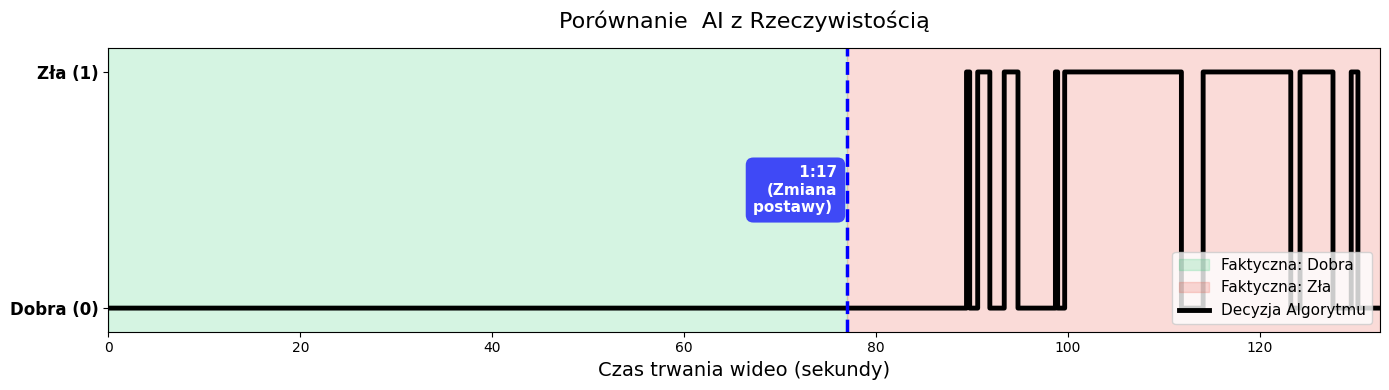

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns
import os

# ==========================================
# 1. Dokładny moment zgarbienia (1 min 17 sek = 77.0 sekund)
# ==========================================
SEKUNDA_ZGARBIENIA = 77.0 

CSV_PATH = "../../data/wyniki_profesor.csv" 
if not os.path.exists(CSV_PATH):
    CSV_PATH = "wyniki_profesor.csv"

if not os.path.exists(CSV_PATH):
    print("❌ BŁĄD: Nie znaleziono pliku wyników.")
else:
    df = pd.read_csv(CSV_PATH)
    
    # Przeliczamy klatki na sekundy
    FPS = 30.0
    df['czas_sekundy'] = df['frame'] / FPS

    # ==========================================
    # 2. Tworzenie Ground Truth (Twoja ocena z oka)
    # ==========================================
    df['ground_truth'] = df['czas_sekundy'].apply(lambda x: 0 if x < SEKUNDA_ZGARBIENIA else 1)

    # ==========================================
    # 3. Wyliczenia Metryk
    # ==========================================
    acc = accuracy_score(df['ground_truth'], df['model_label'])
    
    print(f"--- WYNIKI DLA VIDEO PROF ---")
    print(f"Dokładność Modelu AI: {acc*100:.2f}%")
    print("\nSzczegółowy raport (Precision/Recall):")
    print(classification_report(df['ground_truth'], df['model_label'], target_names=['Dobra (0)', 'Zła (1)']))

    # ==========================================
    # 4. Macierz Konfuzji
    # ==========================================
    cm = confusion_matrix(df['ground_truth'], df['model_label'])
    plt.figure(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', xticklabels=['Dobra', 'Zła'], yticklabels=['Dobra', 'Zła'])
    plt.title('Macierz Konfuzji', fontsize=14, pad=10)
    plt.ylabel('Moja ocena ', fontsize=12)
    plt.xlabel('Ocena AI', fontsize=12)
    plt.show()

    # ==========================================
    # 5. Wykres w czasie (Czytelny status)
    # ==========================================
    fig, ax = plt.subplots(figsize=(14, 4))

    # Tło oznacza Twoją ocenę (zielone = dobra postawa, czerwone = zła postawa)
    ax.fill_between(df['czas_sekundy'], -0.2, 1.2, where=df['ground_truth'] == 0, color='#2ecc71', alpha=0.2, label='Faktyczna: Dobra')
    ax.fill_between(df['czas_sekundy'], -0.2, 1.2, where=df['ground_truth'] == 1, color='#e74c3c', alpha=0.2, label='Faktyczna: Zła')

    # Gruba, czarna linia to decyzja Modelu AI
    ax.step(df['czas_sekundy'], df['model_label'], where='post', color='black', linewidth=3.5, label='Decyzja Algorytmu')

    # Oś Y i limity
    ax.set_yticks([0, 1])
    ax.set_yticklabels(['Dobra (0)', 'Zła (1)'], fontsize=12, fontweight='bold')
    ax.set_xlim(0, df['czas_sekundy'].max())
    ax.set_ylim(-0.1, 1.1)

    plt.title('Porównanie  AI z Rzeczywistością', fontsize=16, pad=15)
    plt.xlabel('Czas trwania wideo (sekundy)', fontsize=14)
    
    # Zaznaczamy dokładnie 1:17 (77. sekundę) przerywaną linią
    ax.axvline(x=SEKUNDA_ZGARBIENIA, color='blue', linestyle='--', linewidth=2.5)
    ax.text(SEKUNDA_ZGARBIENIA - 1, 0.5, ' 1:17\n(Zmiana\npostawy) ', 
            color='white', fontsize=11, fontweight='bold', va='center', ha='right',
            bbox=dict(facecolor='blue', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.5'))

    plt.legend(loc='lower right', fontsize=11)
    plt.tight_layout()
    plt.show()